In [2]:
# coding=utf-8

import os
import torch
import random
import numpy as np
from tqdm import tqdm
from torchvision.utils import save_image
from transformers import CLIPTokenizer, CLIPTextModel
from diffusers import (
    AutoencoderKL,
    UNet2DConditionModel,
    ControlNetModel,
    DDPMScheduler,
)

from PIL import Image
import torch.nn.functional as F

# import lpips

import pandas as pd
import cv2

import matplotlib.pyplot as plt
# plt.use('Qt5Agg')

from torch.utils.data import Dataset


import sys
# from models.dav2.depth_anything_v2.dpt import DepthAnythingV2
# from models.dav2.depth_anything_v2.dpt import DepthAnythingV2


# sys.path.insert(1, '../Training/')
from Training.train_utils.unimatch.unimatch.unimatch import UniMatch
from Training.train_utils.unimatch.utils.flow_viz import flow_to_image
from Training.train_utils.unimatch.utils.visualization import viz_depth_tensor


ModuleNotFoundError: No module named 'tqdm'

In [2]:
def load_sim_images_to_array(path,  num_samples = 0 ):

    images_list_out = []


    images_list = sorted(os.listdir(path))
    image_numbers = [x[-8:-4] for x in images_list]


    if num_samples > 0:

        # random.seed(10)
        indices = random.choices(range(len(image_numbers)), k=num_samples)
        image_numbers = [image_numbers[i] for i in indices]


    for num in image_numbers:

        image_name = f"frame_{num}.png"
        image_path = os.path.join(path, image_name)

        image_pil = Image.open(image_path)
        image = np.asarray(image_pil)
        image = cv2.resize(image, (256, 256), interpolation=cv2.INTER_NEAREST)
        image = image.transpose(2,0,1)
        # print(image.shape)

        images_list_out.append(image)
    
    images_array_out = np.array(images_list_out)
    print(images_array_out.shape)



    return images_array_out     # [N, W, H, 3]

In [3]:

def preprocess_size(image1, image2, padding_factor=32):
    '''
        img: [b, c, h, w]
    '''
    transpose_img = False
    # the model is trained with size: width > height
    if image1.size(-2) > image1.size(-1):
        image1 = torch.transpose(image1, -2, -1)
        image2 = torch.transpose(image2, -2, -1)
        transpose_img = True

    # inference_size = [int(np.ceil(image1.size(-2) / padding_factor)) * padding_factor,
    #                 int(np.ceil(image1.size(-1) / padding_factor)) * padding_factor]
        
    inference_size = [256,256]

    assert isinstance(inference_size, list) or isinstance(inference_size, tuple)
    ori_size = image1.shape[-2:]

    # resize before inference
    if inference_size[0] != ori_size[0] or inference_size[1] != ori_size[1]:
        image1 = F.interpolate(image1, size=inference_size, mode='bilinear',
                                align_corners=True)
        image2 = F.interpolate(image2, size=inference_size, mode='bilinear',
                                align_corners=True)
    
    return image1, image2, inference_size, ori_size, transpose_img


def postprocess_size(flow_pr, inference_size, ori_size, transpose_img):

    if inference_size[0] != ori_size[0] or inference_size[1] != ori_size[1]:
        flow_pr = F.interpolate(flow_pr, size=ori_size, mode='bilinear',
                                align_corners=True)
        flow_pr[:, 0] = flow_pr[:, 0] * ori_size[-1] / inference_size[-1]
        flow_pr[:, 1] = flow_pr[:, 1] * ori_size[-2] / inference_size[-2]

    if transpose_img:
        flow_pr = torch.transpose(flow_pr, -2, -1)
    
    return flow_pr

def get_optical_flows(unimatch, video_frame):
    '''
        video_frame: [b, t, c, w, h]
    '''

    video_frame = video_frame * 255

    # print(video_frame.dtype)

    flows = []
    for i in range(video_frame.shape[1] - 1):
        image1, image2 = video_frame[:, 0], video_frame[:, i + 1]
        # print(image1.dtype)
        image1_r, image2_r, inference_size, ori_size, transpose_img = preprocess_size(image1, image2)
        # print(image1_r.dtype)
        results_dict_r = unimatch(image1_r, image2_r,
            attn_type='swin',
            attn_splits_list=[2, 8],
            corr_radius_list=[-1, 4],
            prop_radius_list=[-1, 1],
            num_reg_refine=6,
            task='flow',
            pred_bidir_flow=False,
            )
        flow_r = results_dict_r['flow_preds'][-1]  # [b, 2, H, W]
        # print(flow_r.shape)
        flow = postprocess_size(flow_r, inference_size, ori_size, transpose_img)
        flows.append(flow.unsqueeze(1))  # [b, 1, 2, w, h]
    
    flows = torch.cat(flows, dim=1).to(torch.float16)  # [b, t, 2, w, h]
    return flows



def get_dav2_flows(depth_anything, pixel_values, write=False):

    depth_frames = []
    depth_imgs = []
    # cmap = matplotlib.colormaps.get_cmap('Spectral_r')
    # print(f'pixel_values::: {pixel_values.shape}')
    # pdb.set_trace()
    for idx in range(pixel_values.shape[0]):
        image = pixel_values[idx,0]
        image = image.clone().detach().cpu().numpy() 
        image = image.transpose(1, 2, 0)

        if image.dtype != np.uint8:
            image = (image * 255).astype(np.uint8)  # Normalize if necessary

        # raw_image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
        depth = np.expand_dims(depth_anything.infer_image(image, 256), axis=(0))
        
        depth_img = (depth - depth.min()) / (depth.max() - depth.min()) * 255.0
        depth_img = depth_img.astype(np.uint8)
        depth_img = np.repeat(depth_img[..., np.newaxis], 3, axis=-1)
        depth_frames.append(depth)
        depth_imgs.append(depth_img)
        if write:
            pass
    depth_imgs = np.array(depth_imgs)
    depth_frames = torch.tensor(np.array(depth_frames))
    # print(f'depth_frames shape : {depth_frames.shape}')
    # print(f'depth_frame shape : {depth.shape}')
    return depth_frames.cuda(), depth_imgs # [b, f-1, 3, h, w]

In [4]:
unimatch = UniMatch(feature_channels=128,
    num_scales=2,
    upsample_factor=4,
    num_head=1,
    ffn_dim_expansion=4,
    num_transformer_layers=6,
    reg_refine=True,
    task='flow').to('cuda')

checkpoint = torch.load('Training/train_utils/unimatch/pretrained/gmflow-scale2-regrefine6-mixdata-train320x576-4e7b215d.pth')
# checkpoint = torch.load('train_utils/unimatch/pretrained/gmflow-scale2-regrefine6-mixdata-train320x576-4e7b215d.pth')



unimatch.load_state_dict(checkpoint['model'])

# unimatch = unimatch.to(accelerator.device).eval()
unimatch.requires_grad_(False)


model_configs = {
    'vits': {'encoder': 'vits', 'features': 64, 'out_channels': [48, 96, 192, 384]},
    'vitb': {'encoder': 'vitb', 'features': 128, 'out_channels': [96, 192, 384, 768]},
    'vitl': {'encoder': 'vitl', 'features': 256, 'out_channels': [256, 512, 1024, 1024]},
    'vitg': {'encoder': 'vitg', 'features': 384, 'out_channels': [1536, 1536, 1536, 1536]}
}


depth_anything = DepthAnythingV2(**model_configs['vitb'])
depth_anything.load_state_dict(torch.load(f'models/dav2/ckpts/depth_anything_v2_vitb.pth', map_location='cpu'))
# depth_anything = depth_anything.to(accelerator.device).eval()
depth_anything.requires_grad_(False)

/tmp/ipykernel_1380095/2513315950.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load('Training/train_utils/unimatch/pretrained/gmflow-scale2-regref

DepthAnythingV2(
  (pretrained): DinoVisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(14, 14), stride=(14, 14))
      (norm): Identity()
    )
    (blocks): ModuleList(
      (0-11): 12 x NestedTensorBlock(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): MemEffAttention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=768, out_features=768, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): LayerScale()
        (drop_path1): Identity()
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (act): GELU(approximate='none')
          (fc2): Linear(in_features=3072, out_features=768, bias=True)
          (drop): Dropout(p=0.0, inplace=False)
    

In [5]:
path = "../ControlNet-diffusers/records_cadis_1/records_single_files/r2"
# MichalMo/projects/ControlNet-diffusers
sim_images_set = load_sim_images_to_array(path, num_samples = 1)

(1, 3, 256, 256)


In [21]:
for i in range(10):
    path = "../ControlNet-diffusers/records_cadis_1/records_single_files/r2"
    # MichalMo/projects/ControlNet-diffusers
    sim_images_set = load_sim_images_to_array(path, num_samples = 1)
    print(sim_images_set.shape)

    sim_images_set2 = torch.Tensor(sim_images_set).unsqueeze(0).cuda()
    print(sim_images_set2.shape)

    val_depths,depth_img = get_dav2_flows(depth_anything.cuda(), sim_images_set2)  
    print(depth_img.shape)

    plt.figure(figsize=(6, 3))
    plt.subplot(121)
    plt.imshow(sim_images_set[0].transpose(1,2,0))
    plt.axis("off")

    plt.subplot(122)
    plt.imshow(depth_img[0,0])
    plt.axis("off")

    plt.show()

(1, 3, 256, 256)
(1, 3, 256, 256)
torch.Size([1, 1, 3, 256, 256])
(1, 1, 256, 256, 3)


ModuleNotFoundError: No module named 'matplotlib_inline'

In [29]:

x = torch.ones([2, 14, 3, 256, 256])
print(x.shape)

val_depths, depth_img = get_dav2_flows(depth_anything.cuda(), x)  
print(val_depths.shape)

plt.imshow(val_depths[0,0])


torch.Size([2, 14, 3, 256, 256])
torch.Size([2, 1, 256, 256])


ModuleNotFoundError: No module named 'matplotlib_inline'

# Create depth images from Simulator

saved in ControlNet-diffusers/records_cadis_1/records_single_files/r_X_depth_synth/

In [7]:
RECORD = "r3"

case_list = sorted(os.listdir(f"../ControlNet-diffusers/records_cadis_1/records_single_files/{RECORD}/"))
image_numbers = [x[-8:-4] for x in case_list]
# for p in range(len(case_list)):
print(len(image_numbers))
print(image_numbers[:10])

# image_numbers = random.choices(image_numbers, k=10)
# image_numbers = ["0021"]

for num in image_numbers[:2]:

    print("NUMBER: ", num)

    img1 = Image.open(f"../ControlNet-diffusers/records_cadis_1/records_single_files/{RECORD}/frame_{num}.png")
    # labels = Image.open(f"records_cadis_1/records_single_files/r3_final/mask_{num}.png")
    img1 = np.asarray(img1)
    img1 = cv2.resize(img1, (256, 256), interpolation=cv2.INTER_NEAREST)

    img1 = img1.transpose(2,0,1)
    img2 = torch.Tensor(img1).unsqueeze(0).unsqueeze(0).cuda()
    print(img2.shape)

    val_depths, depth_img = get_dav2_flows(depth_anything.cuda(), img2)  

    depth_img = depth_img[0,0]
    # print(depth_img.shape)

    save_path= os.path.join(f"../ControlNet-diffusers/records_cadis_1/records_single_files/{RECORD}_depth_synth/depth_{num}.png")
    out_image_pil = Image.fromarray(depth_img)

    # out_image_pil.save(save_path)


140
['0000', '0001', '0002', '0003', '0004', '0005', '0006', '0007', '0008', '0009']
NUMBER:  0000
torch.Size([1, 1, 3, 256, 256])
NUMBER:  0001
torch.Size([1, 1, 3, 256, 256])


# FLOW

(4, 3, 256, 256)
(4, 3, 256, 256)
torch.Size([1, 4, 3, 256, 256])
D torch.Size([1, 3, 2, 256, 256])


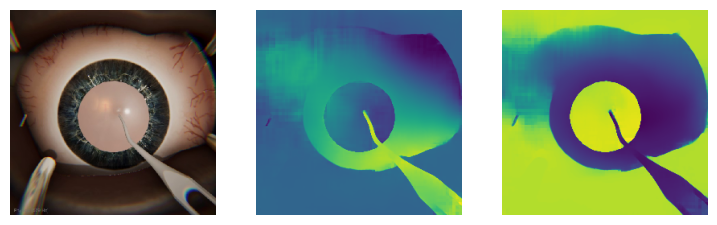

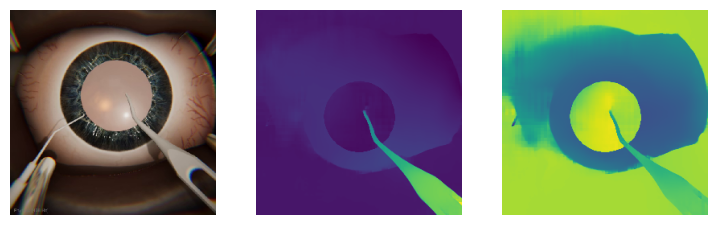

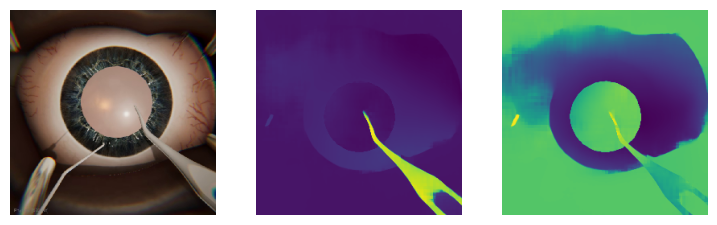

In [64]:
for i in range(1):
    path = "../ControlNet-diffusers/records_cadis_1/records_single_files/r2"
    # MichalMo/projects/ControlNet-diffusers
    sim_images_set = load_sim_images_to_array(path, num_samples = 4)
    print(sim_images_set.shape)

    sim_images_set2 = torch.Tensor(sim_images_set).unsqueeze(0).cuda()
    print(sim_images_set2.shape)

    flows = get_optical_flows(unimatch.cuda(), sim_images_set2)  
    flows= flows.cpu()
    print("D", flows.shape)



    
    for j in range(flows.shape[1]):

        plt.figure(figsize=(9, 3))
        plt.subplot(131)
        plt.imshow(sim_images_set[j].transpose(1,2,0))
        plt.axis("off")

        plt.subplot(132)
        plt.imshow(flows[0,j,0])
        plt.axis("off")

        plt.subplot(133)
        plt.imshow(flows[0,j,1])
        plt.axis("off")

        plt.show()

In [63]:
RECORD = "r2"

case_list = sorted(os.listdir(f"../ControlNet-diffusers/records_cadis_1/records_single_files/{RECORD}/"))
image_numbers = [x[-8:-4] for x in case_list]
# for p in range(len(case_list)):
print(len(image_numbers))
print(image_numbers[:10])

# image_numbers = random.choices(image_numbers, k=10)
# image_numbers = ["0021"]

for num in image_numbers[:1]:

    print("NUMBER: ", num)    


    img1 = Image.open(f"../ControlNet-diffusers/records_cadis_1/records_single_files/{RECORD}/frame_{num}.png")
    # labels = Image.open(f"records_cadis_1/records_single_files/r3_final/mask_{num}.png")
    img1 = np.asarray(img1)
    img1 = cv2.resize(img1, (256, 256), interpolation=cv2.INTER_NEAREST)
    img1 = torch.Tensor(img1.transpose(2,0,1)).unsqueeze(0).cuda()
    
    print(img1.shape)

    flows = get_optical_flows(unimatch.cuda(), img1)  
    flows= flows.cpu()

    print(flows.shape)

    save_path= os.path.join(f"../ControlNet-diffusers/records_cadis_1/records_single_files/{RECORD}_flows_synth/depth_{num}.png")
    # out_image_pil = Image.fromarray(depth_img)


134
['0000', '0001', '0002', '0003', '0004', '0005', '0006', '0007', '0008', '0009']
NUMBER:  0000
torch.Size([1, 3, 256, 256])
torch.Size([1, 2, 2, 256, 256])


# Dataset

In [29]:
import torchvision.transforms as T
from torchvision.utils import make_grid, save_image
import cv2
import albumentations as A
import pandas as pd
import numpy as np





class DatasetMultimodalVideo(Dataset):
    def __init__(self, image_size = 256,  main_path=None, record = None, num_frames = 21, limit_frames = None):
        self.data = []


        self.num_frames = num_frames
        self.record = record
        self.main_path = main_path
        case_list = sorted(os.listdir(os.path.join(self.main_path, record)))
        self.image_numbers = [x[-8:-4] for x in case_list]

        if limit_frames:
            assert (limit_frames > num_frames)
            self.image_numbers = self.image_numbers[:limit_frames]

        self.image_shape = (image_size, image_size)
        # print(len(self.image_numbers))
        # print(self.image_numbers)

        print(f"Loaded {len(self.image_numbers)} samples")


    def __len__(self):
        return len(self.image_numbers) 



    def load_image(self, num, img_type):

        assert img_type in ["image", "mask", "depth"]



        if img_type == "image":
            path = os.path.join(self.main_path, self.record, f"frame_{num}.png")

        elif img_type == "mask":
            path = os.path.join(self.main_path, self.record+ "_final", f"mask_{num}.png")

        elif img_type =="depth":
            path = os.path.join(self.main_path, self.record+ "_depth_synth", f"depth_{num}.png")


        image = Image.open(path)

        image = np.asarray(image)

        if img_type == "image":

            image = cv2.resize(image, self.image_shape, interpolation=cv2.INTER_NEAREST)
            image = np.moveaxis(image, -1, 0)
            image = image / 255.

        elif img_type == "depth":
            image = np.moveaxis(image, -1, 0)


        return image



    def get_batch(self, indexes):

        # base_idx = idx % len(self.df)
        image_list = []
        mask_list = []
        depth_list = []


        for idx in indexes:
            num = self.image_numbers[idx]

            # print(num)

            image = self.load_image(num, "image")
            mask = self.load_image(num, "mask")
            depth = self.load_image(num, "depth")

            image_list.append(image)
            mask_list.append(mask)
            depth_list.append(depth)
        

        images = np.stack(image_list)
        masks = np.stack(mask_list)
        depths = np.stack(depth_list)

        return images, masks, depths


    def __getitem__(self, idx):


        max_start = len(self.image_numbers) - self.num_frames

        # one random iteration
        start_idx = random.randint(0, max_start)
        batch_indexes = range(start_idx, start_idx + self.num_frames)
        # print(batch_indexes)


        images, masks, depths = self.get_batch(batch_indexes)

        # print(images.shape, masks.shape, depths.shape)
        video_name = f"video_{self.record}_{start_idx}_{start_idx + self.num_frames}"




        # print("prompt", prompt, type(prompt)) # depth = torch.tensor(depth)
        return dict(image=torch.tensor(images), mask=torch.tensor(masks), depth = torch.tensor(depths), video_name =video_name)






class DatasetVideoCombined(Dataset):
    def __init__(self, image_size = 256,  main_path=None, records = None, num_frames = 21, limit_frames = None):
        self.data = []


        self.num_frames = num_frames
        self.records = records
        self.main_path = main_path


        self.image_numbers_dict = {}

        for r in records:
            case_list = sorted(os.listdir(os.path.join(self.main_path, r)))
            image_numbers = [x[-8:-4] for x in case_list]
            self.image_numbers_dict[r] = image_numbers

        print(self.image_numbers_dict)

        
        # self.image_numbers sum([key, value in d.items():])
        self.image_numbers_sum = sum(len(v) for v in self.image_numbers_dict.values())
        self.image_shape = (image_size, image_size)


        print(f"Loaded {self.image_numbers_sum} samples")


    def __len__(self):
        return self.image_numbers_sum



    def load_image(self, record, num, img_type):

        assert img_type in ["image", "mask"]



        if img_type == "image":
            path = os.path.join(self.main_path, record, f"frame_{num}.png")

        elif img_type == "mask":
            path = os.path.join(self.main_path, record+ "_final", f"mask_{num}.png")



        image = Image.open(path)

        image = np.asarray(image)

        if img_type == "image":

            image = cv2.resize(image, self.image_shape, interpolation=cv2.INTER_NEAREST)
            image = np.moveaxis(image, -1, 0)
            image = image / 255.


        return image



    def get_batch(self, record, indexes):

        # base_idx = idx % len(self.df)
        image_list = []
        mask_list = []
        depth_list = []


        for idx in indexes:
            num = self.image_numbers_dict[record][idx]

            # print(num)

            image = self.load_image(record, num,  "image")
            mask = self.load_image(record, num, "mask")

            image_list.append(image)
            mask_list.append(mask)
        

        images = np.stack(image_list)
        masks = np.stack(mask_list)

        return images, masks


    def __getitem__(self, idx):


        record =  random.choice(self.records)


        max_start = len(self.image_numbers_dict[record]) - self.num_frames

        # one random iteration
        start_idx = random.randint(0, max_start)
        batch_indexes = range(start_idx, start_idx + self.num_frames)

        print(record)
        print(batch_indexes)


        images, masks = self.get_batch(record, batch_indexes)

        # print(images.shape, masks.shape, depths.shape)
        video_name = f"video_{record}_{start_idx}_{start_idx + self.num_frames}"




        # print("prompt", prompt, type(prompt)) # depth = torch.tensor(depth)
        return dict(image=torch.tensor(images), mask=torch.tensor(masks), video_name =video_name)



In [10]:
record = "r2"

train_dataset = DatasetMultimodalVideo(image_size=256,
                                main_path=f'/home/MichalMo/projects/ControlNet-diffusers/records_cadis_1/records_single_files',
                                record = record,
                                num_frames = 21,
                                limit_frames = 42)


Loaded 42 samples


torch.Size([21, 3, 256, 256]) torch.Size([21, 256, 256]) torch.Size([21, 3, 256, 256])


TypeError: Invalid shape (3, 256, 256) for image data

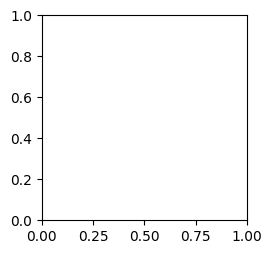

In [11]:
train_dataloader = torch.utils.data.DataLoader(
    train_dataset,
    shuffle=True,
    # collate_fn=collate_fn,
    batch_size=1,
    num_workers=2
)

for step, batch in enumerate(train_dataloader):

    if step == 0:

        image = batch["image"][0]
        mask = batch["mask"][0]
        depth = batch["depth"][0]
        print(image.shape, mask.shape, depth.shape)



        plt.figure(figsize=(9, 3))
        plt.subplot(131)
        plt.imshow(image[0])
        plt.axis("off")

        plt.subplot(132)
        plt.imshow(mask[0])
        plt.axis("off")

        plt.subplot(133)
        plt.imshow(depth[0])
        plt.axis("off")

        plt.show()


        
        break


In [31]:
train_dataset = DatasetVideoCombined(image_size=256,
                                main_path=f'/home/MichalMo/projects/ControlNet-diffusers/records_cadis_1/records_single_files',
                                records = ["r2", "r3"],
                                num_frames = 21)


train_dataloader = torch.utils.data.DataLoader(
    train_dataset,
    shuffle=True,
    # collate_fn=collate_fn,
    batch_size=1,
    num_workers=1
)

for step, batch in enumerate(train_dataloader):

    print(step)

{'r2': ['0000', '0001', '0002', '0003', '0004', '0005', '0006', '0007', '0008', '0009', '0010', '0011', '0012', '0013', '0014', '0015', '0016', '0017', '0018', '0019', '0020', '0021', '0022', '0023', '0024', '0025', '0026', '0027', '0028', '0029', '0030', '0031', '0032', '0033', '0034', '0035', '0036', '0037', '0038', '0039', '0040', '0041', '0042', '0043', '0044', '0045', '0046', '0047', '0048', '0049', '0050', '0051', '0052', '0053', '0054', '0055', '0056', '0057', '0058', '0059', '0060', '0061', '0062', '0063', '0064', '0065', '0066', '0000', '0001', '0002', '0003', '0004', '0005', '0006', '0007', '0008', '0009', '0010', '0011', '0012', '0013', '0014', '0015', '0016', '0017', '0018', '0019', '0020', '0021', '0022', '0023', '0024', '0025', '0026', '0027', '0028', '0029', '0030', '0031', '0032', '0033', '0034', '0035', '0036', '0037', '0038', '0039', '0040', '0041', '0042', '0043', '0044', '0045', '0046', '0047', '0048', '0049', '0050', '0051', '0052', '0053', '0054', '0055', '0056', 

In [36]:
import random

images = list(range(134))  # example list (replace with your image list)

chunk_size = 14
max_start = len(images) - chunk_size

# one random iteration
start_idx = random.randint(0, max_start)
batch = images[start_idx:start_idx + chunk_size]

print("Start index:", start_idx)
print("Batch:", len(batch), batch)


Start index: 117
Batch: 14 [117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130]


In [66]:
from transformers import CLIPImageProcessor, CLIPVisionModelWithProjection

image_encoder = CLIPVisionModelWithProjection.from_pretrained(
   "./Training/ckpts/stable-video-diffusion-img2vid-xt-1-1", subfolder="image_encoder", variant="fp16"
)

In [8]:
# Tests

In [9]:
def get_sam_flows(predictor, pixel_values):
    # cmap = matplotlib.colormaps.get_cmap('Spectral_r')
    # print(f'pixel_values::: {pixel_values.shape}')
    # pdb.set_trace()
    for idx in range(pixel_values.shape[0]):
        image = pixel_values[idx,0]
        image = image.clone().detach().cpu().numpy() 
        image = image.transpose(1, 2, 0)
        if image.dtype != np.uint8:
            image = (image * 255).astype(np.uint8)  # Normalize if necessary
        predictor.set_image(image)
        seg_feature = predictor.features # tensor [1,256,64,64]
        if idx ==0:
            seg_features = seg_feature  
        else:
            seg_features = torch.cat((seg_features, seg_feature), dim=0) 
    

    return seg_features

In [11]:
sam = sam_model_registry["vit_h"](checkpoint="./Training/train_utils/sam/sam_vit_h_4b8939.pth")
sam.to(accelerator.device).eval()
sam.requires_grad_(False)

predictor = SamPredictor(sam)

x = torch.Tensor([2, 14, 3, 256, 256])
o = get_sam_flows(x)
o.shape

TypeError: get_sam_flows() missing 1 required positional argument: 'pixel_values'